<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/Group%2010%2C%20CPE32S3%2C%20CPE%20313%20(Hands-on%20Activity%209.2%20-%20Deployment%20using%20Streamlit).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning: Deployment using Streamlit

---

# Lesson Objectives:
- Deploy a deep learning model locally
- Deploy a deep learning model to the web

# Streamlit

**Streamlit** is an open-source Python framework used for building interactive web applications for data science and machine learning. It allows users to create custom web applications with Python code, enabling data scientists to create user interfaces for their models, visualizations, and data analyses without the need for extensive web development knowledge.

With Streamlit, users can create **web applications** by writing Python scripts that define the layout, content, and behavior of the application. Streamlit provides a **simple and intuitive API** that allows developers to easily create custom widgets, data visualizations, and other user interface components.

Streamlit is designed to be highly modular, allowing users to easily integrate with other Python libraries and tools commonly used in data science and machine learning. Additionally, Streamlit's web server is optimized for fast and efficient updates, allowing users to see changes in real-time as they make updates to their code.

**Requirements**:
- Signup/sign-in to Streamlit account
- Signup/sign-in to Github account
- Create a new environment on Anaconda

**Streamlit Installation on Anaconda**
- Open a new terminal on the newly created environment in Anaconda
- Issue the command `pip install streamlit` to install Streamlit
- To test the installation, issue the command `streamlit hello`. You should have installed Streamlit properly on your environment if you see the page with `Welcome to Streamlit!`.
- For reference, browse to https://docs.streamlit.io/library/get-started for installation procedures on any OS.



# Local Deployment

For this tutorial, I assume that you have created your virtual environment in Python. There are two files necessary to deploy the sample app in Streamlit.

1. **Deep learning model** - in this sample I use the model `plant_classifier.hdf5`. This is to assume that you have develop, trained and tested your deep learning model. You need to save your model, which will be loaded in your Streamlit app later.
- Created a directory of the App
- Placed the model inside the directory

2. **Python Script** - in this sample app, I created a file `app.py` and placed it in the same directory. The content of the `app.py` is shown below.








In [ ]:
import streamlit as st
import tensorflow as tf

@st.cache(allow_output_mutation=True)
def load_model():
  model=tf.keras.models.load_model('plant_classifier.hdf5')
  return model
model=load_model()
st.write("""
# Plant Leaf Detection System"""
)
file=st.file_uploader("Choose plant photo from computer",type=["jpg","png"])

import cv2
from PIL import Image,ImageOps
import numpy as np
def import_and_predict(image_data,model):
    size=(64,64)
    image=ImageOps.fit(image_data,size,Image.ANTIALIAS)
    img=np.asarray(image)
    img_reshape=img[np.newaxis,...]
    prediction=model.predict(img_reshape)
    return prediction
if file is None:
    st.text("Please upload an image file")
else:
    image=Image.open(file)
    st.image(image,use_column_width=True)
    prediction=import_and_predict(image,model)
    class_names=['Alpinia Galanga (Rasna)','Amaranthus Viridis (Arive-Dantu)',
                 'Artocarpus Heterophyllus (Jackfruit)',
                 'Azadirachta Indica (Neem)','Basella Alba (Basale)',
                 'Brassica Juncea (Indian Mustard)','Carissa Carandas (Karanda)',
                 'Citrus Limon (Lemon)','Ficus Auriculata (Roxburgh fig)',
                 'Ficus Religiosa (Peepal Tree)','Hibiscus Rosa-sinensis',
                 'Jasminum (Jasmine)','Mangifera Indica (Mango)',
                 'Mentha (Mint)','Moringa Oleifera (Drumstick)',
                 'Muntingia Calabura (Jamaica Cherry-Gasagase)',
                 'Murraya Koenigii (Curry)', 'Nerium Oleander (Oleander)',
                 'Nyctanthes Arbor-tristis (Parijata)','Ocimum Tenuiflorum (Tulsi)',
                 'Piper Betle (Betel)','Plectranthus Amboinicus (Mexican Mint)',
                 'Pongamia Pinnata (Indian Beech)','Psidium Guajava (Guava)',
                 'Punica Granatum (Pomegranate)','Santalum Album (Sandalwood)',
                 'Syzygium Cumini (Jamun)','Syzygium Jambos (Rose Apple)',
                 'Tabernaemontana Divaricata (Crape Jasmine)',
                 'Trigonella Foenum-graecum (Fenugreek)']
    string="OUTPUT : "+class_names[np.argmax(prediction)]
    st.success(string)

This code uses the **Streamlit** library to create a web application for a **plant leaf detection system**. The user can upload an image of a plant leaf, and the system will predict the plant species.

How the code works:
```
@st.cache(allow_output_mutation=True)
def load_model():
  model=tf.keras.models.load_model('plant_classifier.hdf5')
  return model
```

1. The `load_model()` function uses **TensorFlow** to load a pre-trained neural network model from a saved file. The `@st.cache` decorator is used to cache the function's output, so it is only loaded once and stored in memory for faster access.

```
def import_and_predict(image_data,model):
    size=(64,64)
    image=ImageOps.fit(image_data,size,Image.ANTIALIAS)
    img=np.asarray(image)
    img_reshape=img[np.newaxis,...]
    prediction=model.predict(img_reshape)
    return prediction
```

2. The `import_and_predict()` function takes the uploaded image data and the pre-trained model as input, preprocesses the image by resizing it to (64,64) pixels, and then makes a prediction using the pre-trained model.

```
st.write("""
# Plant Leaf Detection System"""
)
```

3. The **Streamlit library** is used to create the web application's user interface. The `st.write()` function displays the application's title.

```
file=st.file_uploader("Choose plant photo from computer",type=["jpg","png"])
```

4. The `st.file_uploader()` function creates a file uploader widget for the user to upload an image file.

```
st.image(image,use_column_width=True)
```

5. The `st.image()` function displays the uploaded image.

```
st.success(string)
```
6. The `st.success()` function displays the predicted plant species as output.

```
class_names=['Alpinia Galanga (Rasna)','Amaranthus Viridis (Arive-Dantu)','Artocarpus Heterophyllus (Jackfruit)',
    'Azadirachta Indica (Neem)','Basella Alba (Basale)','Brassica Juncea (Indian Mustard)','Carissa Carandas (Karanda)','Citrus Limon (Lemon)','Ficus Auriculata (Roxburgh fig)','Ficus Religiosa (Peepal Tree)', 'Hibiscus Rosa-sinensis','Jasminum (Jasmine)','Mangifera Indica (Mango)', 'Mentha (Mint)','Moringa Oleifera (Drumstick)', 'Muntingia Calabura (Jamaica Cherry-Gasagase)','Murraya Koenigii (Curry)', 'Nerium Oleander (Oleander)','Nyctanthes Arbor-tristis (Parijata)','Ocimum Tenuiflorum (Tulsi)','Piper Betle (Betel)','Plectranthus Amboinicus (Mexican Mint)','Pongamia Pinnata (Indian Beech)','Psidium Guajava (Guava)','Punica Granatum (Pomegranate)', 'Santalum Album (Sandalwood)','Syzygium Cumini (Jamun)',
    'Syzygium Jambos (Rose Apple)', 'Tabernaemontana Divaricata (Crape Jasmine)', 'Trigonella Foenum-graecum (Fenugreek)']
```

7. The `class_names` list contains the names of the plant species that the model can predict.

```
string="OUTPUT : "+class_names[np.argmax(prediction)]
```

8. The `np.argmax()` function is used to find the index of the predicted class with the highest probability, which is then used to get the corresponding plant species name from the `class_names` list.

> Note: This code creates a simple and user-friendly web application for predicting plant species from leaf images using pre-trained neural network models.


In order to run the Streamlit app, notice that we need to install and import the following:
```
import streamlit as st
import tensorflow as tf
import cv2
from PIL import Image,ImageOps
import numpy as np
```




# Web Deployment

**Requirements**:

- Github account
- Streamlit account

**Instructions**:

1. Sign in to Streamlit using either Google account or Github account

<img src= 'https://i.ibb.co/ssMhKZX/Screenshot-2023-05-09-at-5-49-03-PM.png'  width=350/>


2. In the New App button, you can select to create a NEW APP, load existing repo or load from a sample app template.

<img src='https://i.ibb.co/pfr5rHZ/Screenshot-2023-05-09-at-5-53-38-PM.png' width=350 />

3. In this tutorial, click the NEW APP. Supply the information as needed.

<img src='https://i.ibb.co/x7p6N18/Screenshot-2023-05-09-at-5-56-52-PM.png' width=350 />


- Supply the correct path for your Github repository. In my case, I supplied it with the path to the file: `https://github.com/jvtaylar-cpe/streamlit-example`

- Provide the Branch as master
- Lastly, provide the name of your file. In this image, you will see `streamlit_app.py.` In my case, I supplied it with `app.py` which is located in my repository.

You are now ready to deploy the APP.

> **Troubleshooting**: If problems occur, you can troubleshoot the errors in the `Manage App`, which is located on the lower right part of the deployed web app.  

<img src='https://i.ibb.co/tC2XvGm/Screenshot-2023-05-09-at-6-05-39-PM.png' width=600 />



If your APP does not have a problem, it may successfully load and perform the function accordingly. Below is a sample of the successful deployment and testing.

<img src = 'https://i.ibb.co/6PRb4bD/Screenshot-2023-05-09-at-6-11-43-PM.png' width=600 />



> **Important Notes**:
1. Streamlit
2. Google or Github account
3. Environment of your Deep Learning Model


**References**:
1. Learn more on: https://docs.streamlit.io/library/get-started
2. Other deployment: **FLASK** - https://flask.palletsprojects.com/en/2.3.x/


# Supplementary Activity

1. Choose one of the models you've made in the past for a project.
2. Deploy the model using Streamlit.
3. Show proof of deployment.

In [ ]:
# app.py

import streamlit as st
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

# CNN-BiGRU Model
class CNN_BiGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.conv = nn.Conv1d(input_size, 64, kernel_size=3, padding=1)
        self.bigru = nn.GRU(
            input_size=64,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        _, h = self.bigru(x)
        h = torch.cat((h[-2], h[-1]), dim=1)
        h = self.dropout(h)
        return self.fc(h)

NUM_FEATURES = 51
NUM_CLASSES  = 2
HIDDEN_SIZE  = 64
CLASS_LABELS = ['Attack', 'Normal']

# Load Model
@st.cache_resource
def load_model():
    model = CNN_BiGRU(
        input_size=NUM_FEATURES,
        hidden_size=HIDDEN_SIZE,
        num_classes=NUM_CLASSES
    )
    model.load_state_dict(torch.load('cnn_bigru_state_dict.pth', map_location='cpu'))
    model.eval()
    return model

# Streamlit UI
st.set_page_config(page_title="CNN-BiGRU Network Intrusion Detection", layout="wide")
st.title("CNN-BiGRU Intrusion Detection System")
st.write("Upload a CSV file with traffic to classify as **Attack** or **Normal**.")

try:
    model = load_model()
    st.success("Model loaded successfully!")
except FileNotFoundError:
    st.error("Model file 'cnn_bigru_state_dict.pth' not found. Please make sure it's in the same folder as app.py.")
    st.stop()
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop()

# --- File uploader ---
uploaded_file = st.file_uploader("Choose a CSV file", type=["csv"])

if uploaded_file is None:
    st.info("Please upload a CSV file to continue.")
else:
    df = pd.read_csv(uploaded_file)
    st.write("### Preview of Uploaded Data")
    st.dataframe(df.head())

    st.write(f"**Shape:** {df.shape[0]} rows × {df.shape[1]} columns")

    # --- Check feature count ---
    if df.shape[1] != NUM_FEATURES:
        st.error(f"Expected {NUM_FEATURES} features, but got {df.shape[1]}. Please check your CSV.")
        st.stop()

    try:
        # --- Preprocess ---
        data = df.values.astype(np.float32)
        data_tensor = torch.tensor(data).unsqueeze(1)

        # --- Predict ---
        with torch.no_grad():
            outputs = model(data_tensor)
            probabilities = torch.softmax(outputs, dim=1).numpy()
            predictions = np.argmax(probabilities, axis=1)

        # --- results ---
        predicted_labels = [CLASS_LABELS[p] for p in predictions]
        attack_probs = probabilities[:, 0] * 100
        normal_probs = probabilities[:, 1] * 100

        results_df = df.copy()
        results_df['Prediction']       = predicted_labels
        results_df['Attack Prob (%)']  = attack_probs.round(2)
        results_df['Normal Prob (%)']  = normal_probs.round(2)

        st.write("### Prediction Results")
        st.dataframe(results_df[['Prediction', 'Attack Prob (%)', 'Normal Prob (%)']])

        attack_count = predicted_labels.count('Attack')
        normal_count = predicted_labels.count('Normal')

        col1, col2, col3 = st.columns(3)
        col1.metric("Total Samples", len(predicted_labels))
        col2.metric("Attack", attack_count)
        col3.metric("Normal", normal_count)

        if attack_count > 0:
            st.warning(f"{attack_count} attack(s) detected in the uploaded data!")
        else:
            st.success("No attacks detected. All traffic appears normal.")

    except Exception as e:
        st.error(f"Prediction error: {e}")

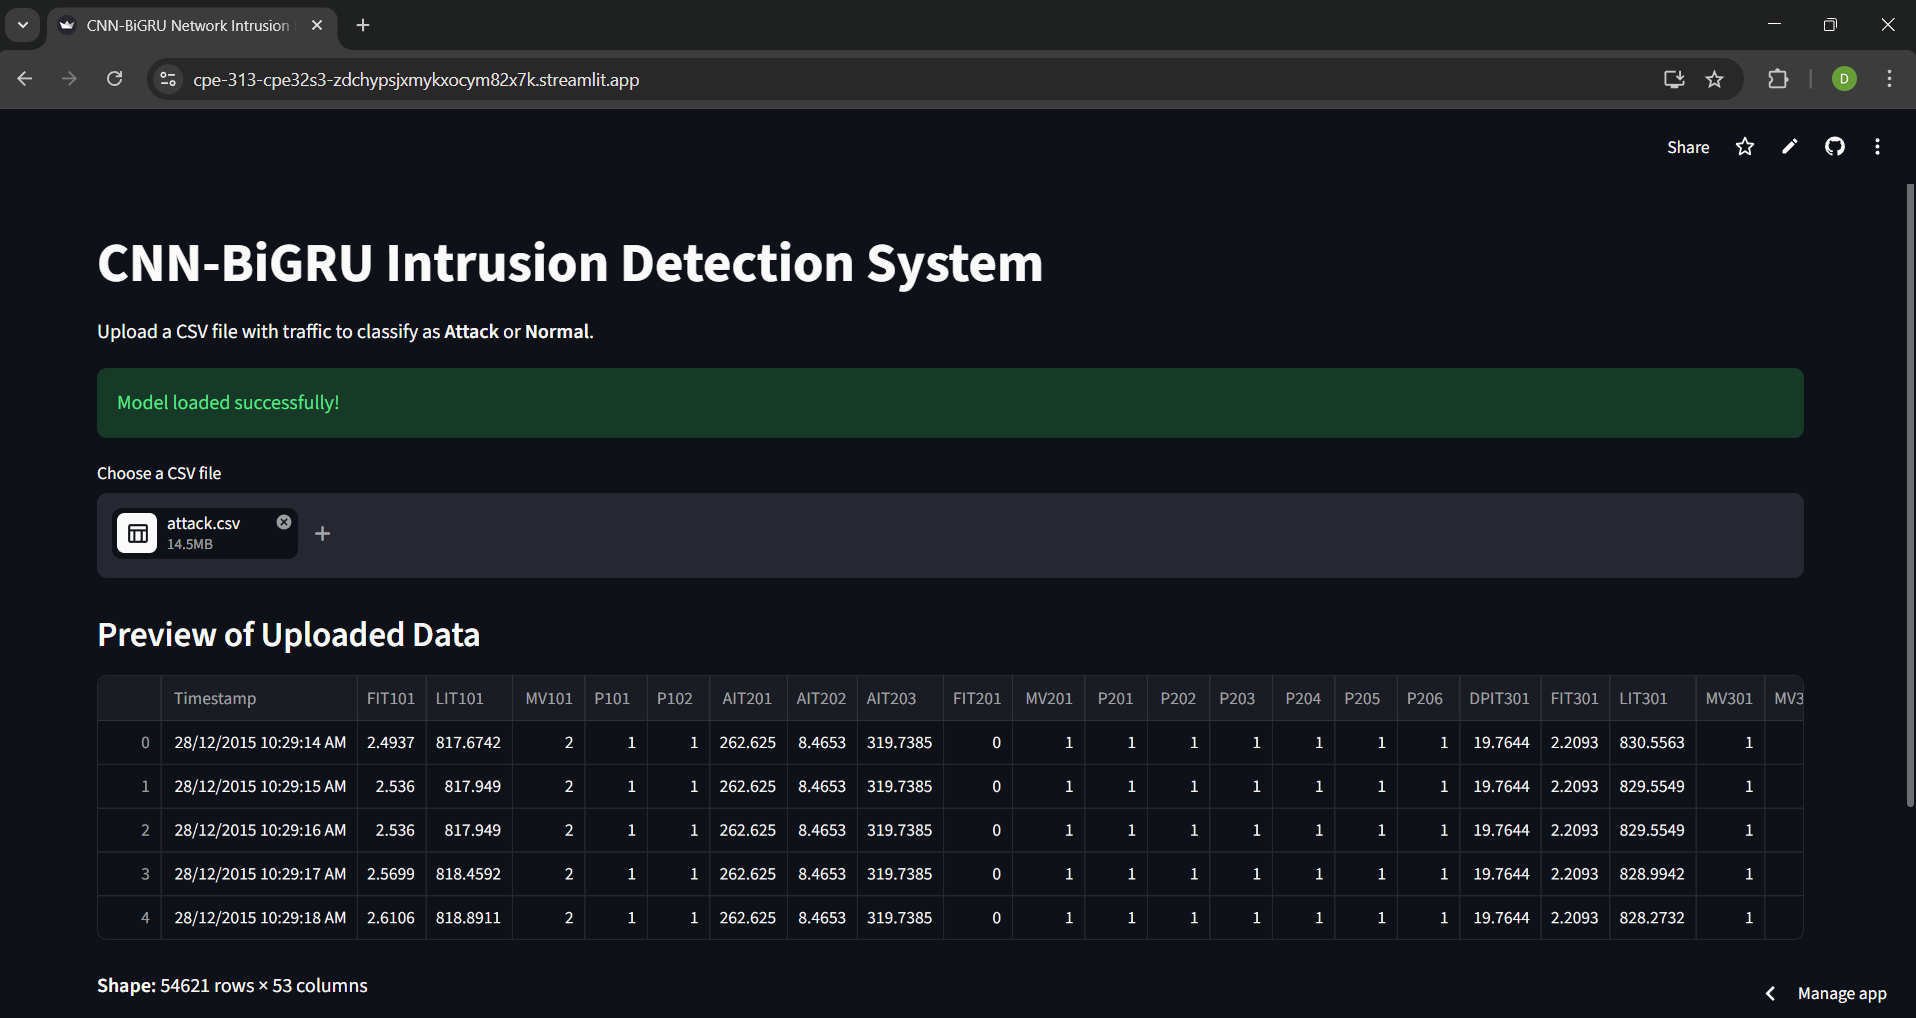

**Analysis:** We deployed a CNN-BiGRU deep learning model using Streamlit, creating a Intrusion Detection System that classifies traffic as either Attack or Normal. The app was first tested locally through streamlit run app.py. It was then deployed online through Streamlit Community Cloud by connecting it to a GitHub repository, giving it a public accessible link.

# Conclusion

Fernandez, Don Eleazar T.
- From this activity, I understood that deployment is what brings a project to life because it allows users to interact with the model directly. I learned that even if a model performs well, it still needs a clear and simple interface to be effective. Working with Streamlit showed me how to present outputs in a way that is easy to follow. In the end, this activity helped me appreciate the importance of both functionality and user experience in completing a project.

Valleser, Kenn Jie L.
- Through this activity, I realized that building a model is only part of the work, and deploying it using Streamlit makes it actually useful for others. I learned how important it is to make the model easy to access and understand, not just accurate. The process helped me see how everything connects, from training the model to presenting the results in a simple interface. Overall, it made me more confident in turning technical work into something practical and usable.


#